In [10]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 21.0 MB/s eta 0:00:00


In [ ]:
!pip install torch torchvision torchaudio

In [ ]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.5/511.5 kB 28.2 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 59.0 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.1/774.1 kB 42.0 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 17.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 81.3 MB/s eta 0:00:00


In [ ]:
import os, sys, warnings, math, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')

# RDKit
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, AllChem, Draw, rdMolDescriptors, QED
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

# ML / DL
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score, mean_squared_error, r2_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
import shap
from imblearn.over_sampling import SMOTE
from tqdm import tqdm

# PyG
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, global_max_pool

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

Device: cuda


In [3]:
from google.colab import files
uploaded = files.upload()  # A file picker button will appear — click it and select your ZIP

Saving datasets.zip to datasets.zip


In [4]:
import zipfile, os

zip_name = list(uploaded.keys())[0]          # auto-detects your zip filename
extract_path = '/content/drug_data/'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(extract_path)

# Verify all files are there
for f in os.listdir(extract_path):
    size = os.path.getsize(os.path.join(extract_path, f))
    print(f" {f:50s}  {size/1024/1024:.2f} MB")

 interactions_cleaned (2).csv                        0.11 MB
 clintox (1).csv                                     0.09 MB
 drug_protein_diagnosis.csv                          0.01 MB
 lp_pdbbind_cleaned.csv                              4.20 MB
 generated_candidates.csv                            0.00 MB
 tox21_cleaned.csv                                   0.55 MB
 drug_filtered (1).csv                               79.77 MB
 master_drug_discovery.csv                           998.18 MB
 existing_candidates_ranked.csv                      0.02 MB
 drug_cleaned.csv                                    9.32 MB


In [5]:
import pandas as pd

BASE = '/content/drug_data/'

datasets = {
    'clintox':           pd.read_csv(f'{BASE}clintox (1).csv'),
    'drug_cleaned':      pd.read_csv(f'{BASE}drug_cleaned.csv'),
    'drug_filtered':     pd.read_csv(f'{BASE}drug_filtered (1).csv'),
    'drug_protein':      pd.read_csv(f'{BASE}drug_protein_diagnosis.csv'),
    'existing_ranked':   pd.read_csv(f'{BASE}existing_candidates_ranked.csv'),
    'generated':         pd.read_csv(f'{BASE}generated_candidates.csv'),
    'interactions':      pd.read_csv(f'{BASE}interactions_cleaned (2).csv'),
    'lp_pdbbind':        pd.read_csv(f'{BASE}lp_pdbbind_cleaned.csv'),
    'master':            pd.read_csv(f'{BASE}master_drug_discovery.csv'),
    'tox21':             pd.read_csv(f'{BASE}tox21_cleaned.csv'),
}

print("=== All Datasets Loaded ===")
print(f"{'Name':25s}  {'Rows':>8}  {'Cols':>5}  Columns")
print("-" * 80)
for name, df in datasets.items():
    print(f"  {name:23s}  {df.shape[0]:>8,}  {df.shape[1]:>5}  {list(df.columns[:4])}...")

print("\n All datasets ready — proceed to drug-likeness pipeline!")

=== All Datasets Loaded ===
Name                           Rows   Cols  Columns
--------------------------------------------------------------------------------
  clintox                     1,484      3  ['smiles', 'FDA_APPROVED', 'CT_TOX']...
  drug_cleaned               76,543     16  ['ID', 'score', 'SMILES', 'target']...
  drug_filtered             637,292     16  ['ID', 'score', 'SMILES', 'target']...
  drug_protein                   99      7  ['drug_name', 'drug_smiles', 'protein_name', 'protein_sequence']...
  existing_ranked               100     12  ['smiles', 'MW', 'LogP', 'TPSA']...
  generated                       9     10  ['smiles', 'MW', 'LogP', 'TPSA']...
  interactions                  750     16  ['protein_name', 'protein_id', 'gene_symbol', 'uniprot_id']...
  lp_pdbbind                 10,336     10  ['pdb_id', 'ligand_smiles', 'protein_sequence', 'binding_affinity']...
  master                   3,002,272     18  ['smiles', 'target_name', 'affinity_type', 'affini

In [6]:
# ─── Print all column names per dataset ───
# This is critical so we know exact SMILES column names before building features

for name, df in datasets.items():
    print(f"\n{'─'*60}")
    print(f"  📋 {name.upper()}  ({df.shape[0]:,} rows)")
    print(f"{'─'*60}")
    for i, col in enumerate(df.columns):
        dtype = str(df[col].dtype)
        nulls = df[col].isnull().sum()
        null_pct = nulls / len(df) * 100
        print(f"    [{i:02d}] {col:<35} {dtype:<12} nulls={nulls:,} ({null_pct:.1f}%)")


────────────────────────────────────────────────────────────
  📋 CLINTOX  (1,484 rows)
────────────────────────────────────────────────────────────
    [00] smiles                              object       nulls=0 (0.0%)
    [01] FDA_APPROVED                        int64        nulls=0 (0.0%)
    [02] CT_TOX                              int64        nulls=0 (0.0%)

────────────────────────────────────────────────────────────
  📋 DRUG_CLEANED  (76,543 rows)
────────────────────────────────────────────────────────────
    [00] ID                                  object       nulls=0 (0.0%)
    [01] score                               float64      nulls=0 (0.0%)
    [02] SMILES                              object       nulls=0 (0.0%)
    [03] target                              object       nulls=0 (0.0%)
    [04] MW                                  float64      nulls=0 (0.0%)
    [05] XLogP                               float64      nulls=0 (0.0%)
    [06] HBA                           

In [7]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/drug_data/'

print("Loading datasets...")

clintox          = pd.read_csv(f'{BASE}clintox (1).csv')
drug_cleaned     = pd.read_csv(f'{BASE}drug_cleaned.csv')
drug_filtered    = pd.read_csv(f'{BASE}drug_filtered (1).csv')
drug_protein     = pd.read_csv(f'{BASE}drug_protein_diagnosis.csv')
existing_ranked  = pd.read_csv(f'{BASE}existing_candidates_ranked.csv')
generated        = pd.read_csv(f'{BASE}generated_candidates.csv')
interactions     = pd.read_csv(f'{BASE}interactions_cleaned (2).csv')
lp_pdbbind       = pd.read_csv(f'{BASE}lp_pdbbind_cleaned.csv')
master           = pd.read_csv(f'{BASE}master_drug_discovery.csv')
tox21            = pd.read_csv(f'{BASE}tox21_cleaned.csv')

print("All datasets loaded!")
print(f"  clintox          : {clintox.shape}")
print(f"  drug_cleaned     : {drug_cleaned.shape}")
print(f"  drug_filtered    : {drug_filtered.shape}")
print(f"  drug_protein     : {drug_protein.shape}")
print(f"  existing_ranked  : {existing_ranked.shape}")
print(f"  generated        : {generated.shape}")
print(f"  interactions     : {interactions.shape}")
print(f"  lp_pdbbind       : {lp_pdbbind.shape}")
print(f"  master           : {master.shape}")
print(f"  tox21            : {tox21.shape}")

Loading datasets...
All datasets loaded!
  clintox          : (1484, 3)
  drug_cleaned     : (76543, 16)
  drug_filtered    : (637292, 16)
  drug_protein     : (99, 7)
  existing_ranked  : (100, 12)
  generated        : (9, 10)
  interactions     : (750, 16)
  lp_pdbbind       : (10336, 10)
  master           : (3002272, 18)
  tox21            : (7831, 16)


In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, rdMolDescriptors, QED
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import shap
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f"Imports done | Device: {DEVICE} | PyTorch: {torch.__version__}")

Imports done | Device: cuda | PyTorch: 2.10.0+cu128


In [12]:
def compute_all_descriptors(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    d = {}

    # Lipinski Ro5
    d['MW']               = Descriptors.MolWt(mol)
    d['LogP']             = Descriptors.MolLogP(mol)
    d['HBD']              = Descriptors.NumHDonors(mol)
    d['HBA']              = Descriptors.NumHAcceptors(mol)

    # Veber
    d['TPSA']             = Descriptors.TPSA(mol)
    d['RotBonds']         = Descriptors.NumRotatableBonds(mol)

    # Ghose
    d['MR']               = Descriptors.MolMR(mol)
    d['HeavyAtoms']       = Descriptors.HeavyAtomCount(mol)

    # Structural
    d['RingCount']        = Descriptors.RingCount(mol)
    d['AromaticRings']    = Descriptors.NumAromaticRings(mol)
    d['AliphaticRings']   = Descriptors.NumAliphaticRings(mol)
    d['SaturatedRings']   = Descriptors.NumSaturatedRings(mol)
    d['FractionCSP3']     = Descriptors.FractionCSP3(mol)
    d['Heteroatoms']      = Descriptors.NumHeteroatoms(mol)
    d['NHOHCount']        = Descriptors.NHOHCount(mol)
    d['NOCount']          = Descriptors.NOCount(mol)
    d['Stereocenters']    = rdMolDescriptors.CalcNumAtomStereoCenters(mol)
    d['HalogenCount']     = sum(1 for a in mol.GetAtoms()
                                if a.GetAtomicNum() in [9,17,35,53])

    # Electronic
    d['MaxPartialCharge'] = Descriptors.MaxPartialCharge(mol) or 0.0
    d['MinPartialCharge'] = Descriptors.MinPartialCharge(mol) or 0.0
    d['ExactMW']          = Descriptors.ExactMolWt(mol)
    d['ValenceElectrons'] = Descriptors.NumValenceElectrons(mol)

    # Topological
    d['Complexity']       = Descriptors.BertzCT(mol)
    d['HallKierAlpha']    = Descriptors.HallKierAlpha(mol)
    d['Kappa1']           = Descriptors.Kappa1(mol)
    d['Kappa2']           = Descriptors.Kappa2(mol)
    d['Kappa3']           = Descriptors.Kappa3(mol)
    d['Chi0']             = Descriptors.Chi0(mol)
    d['Chi1']             = Descriptors.Chi1(mol)
    d['LabuteASA']        = Descriptors.LabuteASA(mol)
    d['PEOE_VSA1']        = Descriptors.PEOE_VSA1(mol)
    d['SMR_VSA1']         = Descriptors.SMR_VSA1(mol)
    d['SlogP_VSA1']       = Descriptors.SlogP_VSA1(mol)

    # QED
    try:
        d['QED'] = QED.qed(mol)
    except:
        d['QED'] = 0.0

    # PAINS
    params = FilterCatalogParams()
    params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
    catalog = FilterCatalog(params)
    d['PAINS_alert'] = int(catalog.HasMatch(mol))

    return d


def multi_class_label(row):
    qed      = row.get('QED', 0)
    lip_viol = sum([row.get('MW',9999)>500, row.get('LogP',99)>5,
                    row.get('HBD',99)>5,    row.get('HBA',99)>10])
    veber_ok = (row.get('TPSA',999)<=140 and row.get('RotBonds',99)<=10)
    pains    = row.get('PAINS_alert', 1)

    if qed >= 0.6 and lip_viol == 0 and veber_ok and pains == 0: return 3
    elif qed >= 0.4 and lip_viol <= 1 and veber_ok:               return 2
    elif qed >= 0.2:                                               return 1
    else:                                                          return 0

def binary_label(cls):
    return 1 if cls >= 2 else 0

print("Functions ready!")

Functions ready!


In [15]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import QED
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from tqdm import tqdm
warnings.filterwarnings('ignore')

print("=" * 55)
print("  Building Master Dataset from Existing Descriptors")
print("=" * 55)

# ─── 1. drug_cleaned — already has all key descriptors ───
dc = drug_cleaned[['SMILES','MW','XLogP','HBA','HBD',
                    'TPSA_NO','RotBondCount','HAC',
                    'AromaticRingCount','HalogenCount']].copy()
dc.columns = ['smiles','MW','LogP','HBA','HBD',
               'TPSA','RotBonds','HeavyAtoms',
               'AromaticRings','HalogenCount']
dc['source'] = 'drug_cleaned'
print(f"  drug_cleaned     : {len(dc):,} rows")

# ─── 2. drug_filtered — same structure as drug_cleaned ───
df_filt = drug_filtered[['SMILES','MW','XLogP','HBA','HBD',
                           'TPSA_NO','RotBondCount','HAC',
                           'AromaticRingCount','HalogenCount']].copy()
df_filt.columns = ['smiles','MW','LogP','HBA','HBD',
                    'TPSA','RotBonds','HeavyAtoms',
                    'AromaticRings','HalogenCount']
df_filt['source'] = 'drug_filtered'
# Sample 50K — no need for all 637K
df_filt = df_filt.sample(n=50000, random_state=RANDOM_STATE)
print(f"  drug_filtered    : {len(df_filt):,} rows (sampled)")

# ─── 3. existing_ranked — already fully scored ───
er = existing_ranked[['smiles','MW','LogP','TPSA','HBD','HBA']].copy()
er['RotBonds']     = np.nan
er['HeavyAtoms']   = np.nan
er['AromaticRings']= np.nan
er['HalogenCount'] = np.nan
er['source']       = 'existing_ranked'
print(f"  existing_ranked  : {len(er):,} rows")

# ─── 4. generated — your novel molecules ───
gen = generated[['smiles','MW','LogP','TPSA','HBD','HBA']].copy()
gen['RotBonds']     = np.nan
gen['HeavyAtoms']   = np.nan
gen['AromaticRings']= np.nan
gen['HalogenCount'] = np.nan
gen['source']       = 'generated'
print(f"  generated        : {len(gen):,} rows")

# ─── 5. clintox — only has SMILES, compute 6 key descriptors (fast, 1484 rows) ───
print(f"\n  clintox: computing descriptors for {len(clintox):,} rows (fast)...")
clintox_records = []
for smi in tqdm(clintox['smiles'], desc='  clintox'):
    mol = Chem.MolFromSmiles(str(smi))
    if mol:
        from rdkit.Chem import Descriptors
        clintox_records.append({
            'smiles'      : smi,
            'MW'          : Descriptors.MolWt(mol),
            'LogP'        : Descriptors.MolLogP(mol),
            'HBD'         : Descriptors.NumHDonors(mol),
            'HBA'         : Descriptors.NumHAcceptors(mol),
            'TPSA'        : Descriptors.TPSA(mol),
            'RotBonds'    : Descriptors.NumRotatableBonds(mol),
            'HeavyAtoms'  : Descriptors.HeavyAtomCount(mol),
            'AromaticRings': Descriptors.NumAromaticRings(mol),
            'HalogenCount': sum(1 for a in mol.GetAtoms()
                                if a.GetAtomicNum() in [9,17,35,53]),
            'source'      : 'clintox'
        })
clintox_desc = pd.DataFrame(clintox_records)
print(f"  clintox          : {len(clintox_desc):,} rows")

# ─── 6. tox21 — only 7831 rows, fast ───
print(f"  tox21: computing descriptors for {len(tox21):,} rows (fast)...")
tox21_records = []
for smi in tqdm(tox21['drug_smiles'], desc='  tox21'):
    mol = Chem.MolFromSmiles(str(smi))
    if mol:
        from rdkit.Chem import Descriptors
        tox21_records.append({
            'smiles'      : smi,
            'MW'          : Descriptors.MolWt(mol),
            'LogP'        : Descriptors.MolLogP(mol),
            'HBD'         : Descriptors.NumHDonors(mol),
            'HBA'         : Descriptors.NumHAcceptors(mol),
            'TPSA'        : Descriptors.TPSA(mol),
            'RotBonds'    : Descriptors.NumRotatableBonds(mol),
            'HeavyAtoms'  : Descriptors.HeavyAtomCount(mol),
            'AromaticRings': Descriptors.NumAromaticRings(mol),
            'HalogenCount': sum(1 for a in mol.GetAtoms()
                                if a.GetAtomicNum() in [9,17,35,53]),
            'source'      : 'tox21'
        })
tox21_desc = pd.DataFrame(tox21_records)
print(f"  tox21            : {len(tox21_desc):,} rows")

# ─── Combine all sources ───
master_desc = pd.concat([
    dc, df_filt, er, gen, clintox_desc, tox21_desc
], ignore_index=True)

master_desc.dropna(subset=['smiles','MW','LogP','HBD','HBA','TPSA'], inplace=True)
master_desc.drop_duplicates(subset='smiles', inplace=True)
master_desc.reset_index(drop=True, inplace=True)

# ─── Add QED (fast — only needs SMILES, vectorized) ───
print(f"\n  Computing QED for {len(master_desc):,} molecules...")
qed_vals = []
for smi in tqdm(master_desc['smiles'], desc='  QED'):
    try:
        mol = Chem.MolFromSmiles(str(smi))
        qed_vals.append(QED.qed(mol) if mol else 0.0)
    except:
        qed_vals.append(0.0)
master_desc['QED'] = qed_vals

# ─── Labels ───
def assign_labels(row):
    qed      = row.get('QED', 0)
    lip_viol = sum([row.get('MW',9999)>500, row.get('LogP',99)>5,
                    row.get('HBD',99)>5,    row.get('HBA',99)>10])
    veber_ok = (row.get('TPSA',999)<=140 and
                row.get('RotBonds',99)<=10)
    if   qed >= 0.6 and lip_viol == 0 and veber_ok: return 3
    elif qed >= 0.4 and lip_viol <= 1 and veber_ok: return 2
    elif qed >= 0.2:                                 return 1
    else:                                            return 0

master_desc['drug_like_class']  = master_desc.apply(assign_labels, axis=1)
master_desc['drug_like_binary'] = (master_desc['drug_like_class'] >= 2).astype(int)

# ─── Final Summary ───
print("\n" + "=" * 55)
print("  MASTER DATASET SUMMARY")
print("=" * 55)
print(f"  Total molecules  : {len(master_desc):,}")
print(f"  Total columns    : {master_desc.shape[1]}")

print(f"\n  4-Class Distribution:")
class_names = {0:'Non-drug-like', 1:'Borderline',
               2:'Drug-like',     3:'Highly Drug-like'}
for cls, name in class_names.items():
    n   = (master_desc['drug_like_class'] == cls).sum()
    pct = n / len(master_desc) * 100
    bar = '█' * int(pct / 2)
    print(f"    Class {cls} {name:<18}: {n:>7,} ({pct:5.1f}%) {bar}")

print(f"\n  Binary Distribution:")
n1 = master_desc['drug_like_binary'].sum()
n0 = len(master_desc) - n1
print(f"    Drug-like     (1): {n1:>7,} ({n1/len(master_desc)*100:.1f}%)")
print(f"    Non-drug-like (0): {n0:>7,} ({n0/len(master_desc)*100:.1f}%)")

print(f"\n  Per-Source Breakdown:")
print(master_desc['source'].value_counts().to_string())

master_desc.to_csv('/content/master_descriptors.csv', index=False)
print(f"\n Done! Saved → /content/master_descriptors.csv")

  Building Master Dataset from Existing Descriptors
  drug_cleaned     : 76,543 rows
  drug_filtered    : 50,000 rows (sampled)
  existing_ranked  : 100 rows
  generated        : 9 rows

  clintox: computing descriptors for 1,484 rows (fast)...


  clintox:  75%|███████▌  | 1119/1484 [00:00<00:00, 1129.33it/s][10:53:07] Can't kekulize mol.  Unkekulized atoms: 4
[10:53:07] Can't kekulize mol.  Unkekulized atoms: 4
  clintox: 100%|██████████| 1484/1484 [00:01<00:00, 1214.15it/s]


  clintox          : 1,480 rows
  tox21: computing descriptors for 7,831 rows (fast)...


  tox21:  28%|██▊       | 2179/7831 [00:01<00:03, 1493.78it/s][10:53:08] Explicit valence for atom # 3 Al, 6, is greater than permitted
[10:53:08] Explicit valence for atom # 4 Al, 6, is greater than permitted
  tox21:  57%|█████▋    | 4496/7831 [00:02<00:02, 1639.70it/s][10:53:10] Explicit valence for atom # 9 Al, 6, is greater than permitted
[10:53:10] Explicit valence for atom # 5 Al, 6, is greater than permitted
  tox21: 100%|██████████| 7831/7831 [00:04<00:00, 1597.31it/s]


  tox21            : 7,823 rows

  Computing QED for 94,034 molecules...


  QED:  43%|████▎     | 40856/94034 [01:08<01:15, 701.93it/s][10:54:21] Conflicting single bond directions around double bond at index 10.
[10:54:21]   BondStereo set to STEREONONE and single bond directions set to NONE.
  QED:  50%|█████     | 47256/94034 [01:19<01:32, 507.55it/s][10:54:32] Conflicting single bond directions around double bond at index 6.
[10:54:32]   BondStereo set to STEREONONE and single bond directions set to NONE.
  QED:  53%|█████▎    | 50002/94034 [01:23<01:31, 479.12it/s][10:54:36] Conflicting single bond directions around double bond at index 5.
[10:54:36]   BondStereo set to STEREONONE and single bond directions set to NONE.
  QED:  59%|█████▉    | 55811/94034 [01:32<00:51, 736.26it/s][10:54:45] Conflicting single bond directions around double bond at index 6.
[10:54:45]   BondStereo set to STEREONONE and single bond directions set to NONE.
  QED:  85%|████████▍ | 79888/94034 [02:10<00:22, 619.47it/s][10:55:22] Conflicting single bond directions around doubl


  MASTER DATASET SUMMARY
  Total molecules  : 94,034
  Total columns    : 14

  4-Class Distribution:
    Class 0 Non-drug-like     :     623 (  0.7%) 
    Class 1 Borderline        :   5,386 (  5.7%) ██
    Class 2 Drug-like         :  20,713 ( 22.0%) ███████████
    Class 3 Highly Drug-like  :  67,312 ( 71.6%) ███████████████████████████████████

  Binary Distribution:
    Drug-like     (1):  88,025 (93.6%)
    Non-drug-like (0):   6,009 (6.4%)

  Per-Source Breakdown:
source
drug_cleaned     76543
drug_filtered     8233
tox21             7769
clintox           1480
generated            9

 Done! Saved → /content/master_descriptors.csv


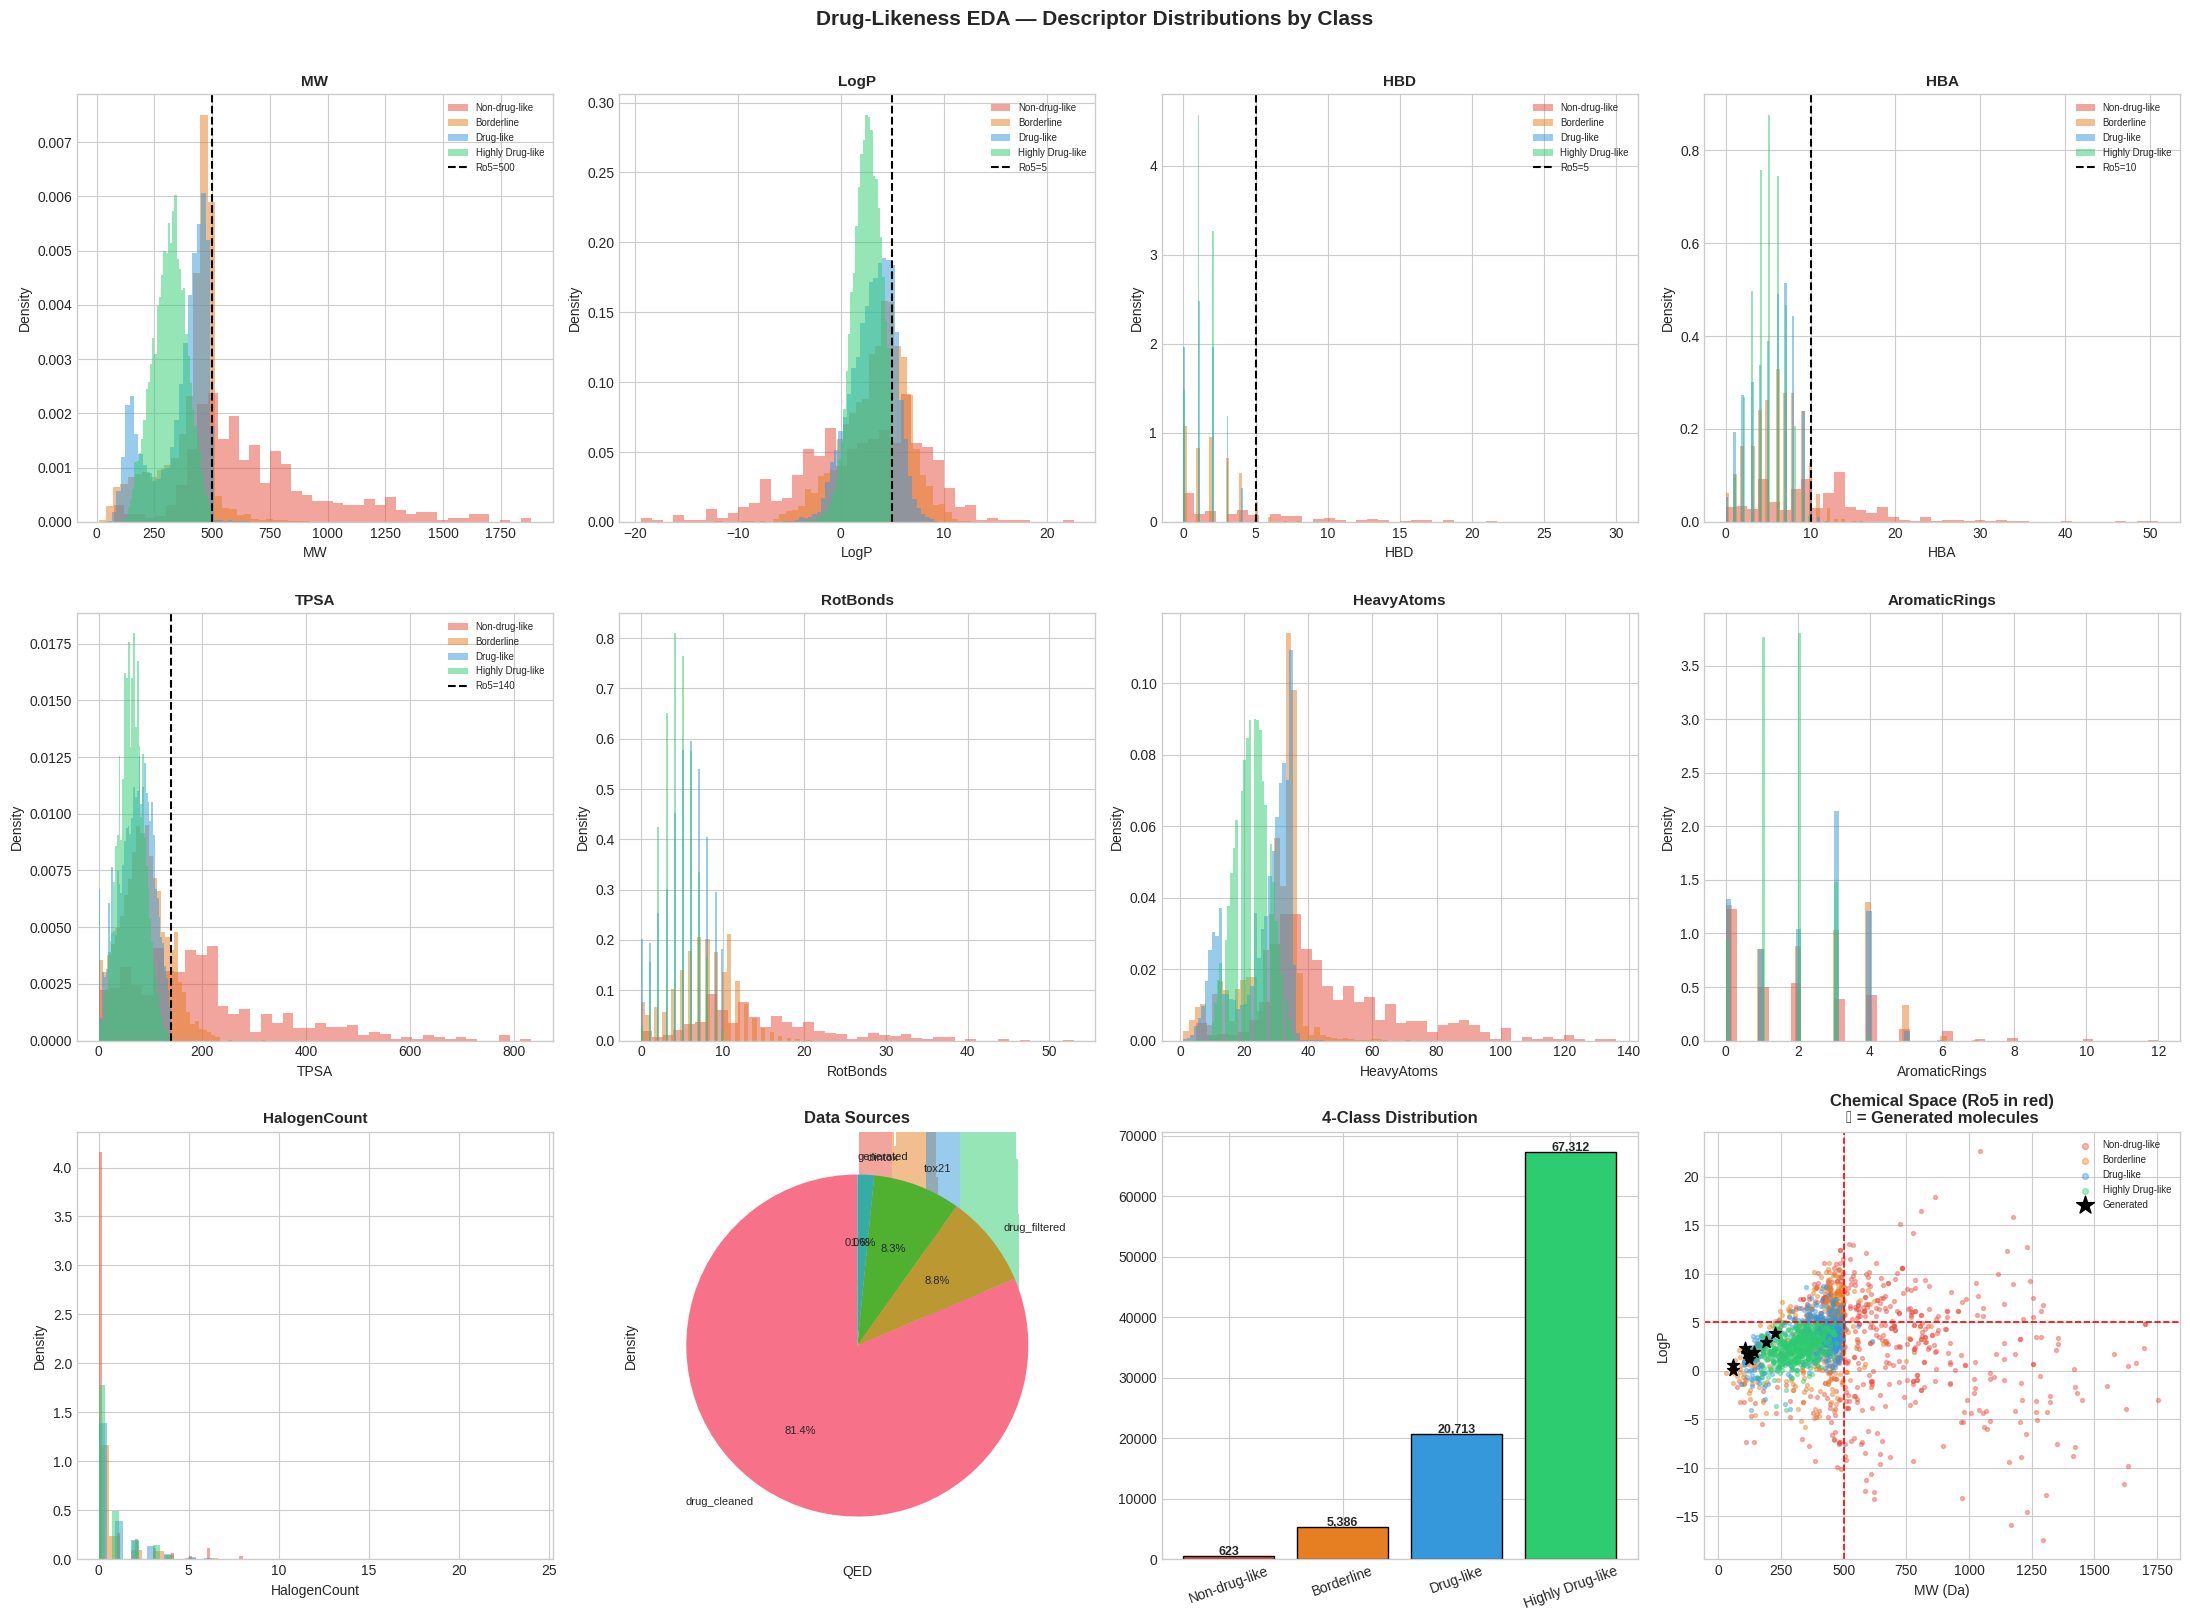

 Saved → /content/eda_distributions.png


In [16]:
# ─── EDA: Understand your data visually before training ───

FEATURE_COLS = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds',
                'HeavyAtoms', 'AromaticRings', 'HalogenCount', 'QED']

palette     = {0:'#e74c3c', 1:'#e67e22', 2:'#3498db', 3:'#2ecc71'}
class_names = {0:'Non-drug-like', 1:'Borderline',
               2:'Drug-like',     3:'Highly Drug-like'}

fig, axes = plt.subplots(3, 4, figsize=(22, 16))
axes = axes.flatten()

# ── 1-8: Descriptor distributions by class ──
for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    for cls in [0, 1, 2, 3]:
        subset = master_desc[master_desc['drug_like_class'] == cls][col].dropna()
        ax.hist(subset, bins=40, alpha=0.5, color=palette[cls],
                label=class_names[cls], density=True)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    if i == 0:
        ax.legend(fontsize=7)

# Lipinski reference lines
refs = {'MW':500, 'LogP':5, 'HBD':5, 'HBA':10, 'TPSA':140}
for col, val in refs.items():
    if col in FEATURE_COLS:
        idx = FEATURE_COLS.index(col)
        axes[idx].axvline(val, color='black', linestyle='--',
                          linewidth=1.5, label=f'Ro5={val}')
        axes[idx].legend(fontsize=7)

# ── 9: Class distribution bar ──
ax9 = axes[10]
counts = master_desc['drug_like_class'].value_counts().sort_index()
bars   = ax9.bar([class_names[c] for c in counts.index],
                  counts.values,
                  color=[palette[c] for c in counts.index],
                  edgecolor='black')
for bar in bars:
    h = bar.get_height()
    ax9.text(bar.get_x()+bar.get_width()/2, h+100,
             f'{h:,}', ha='center', fontsize=9, fontweight='bold')
ax9.set_title('4-Class Distribution', fontweight='bold')
ax9.tick_params(axis='x', rotation=20)

# ── 10: MW vs LogP chemical space ──
ax10 = axes[11]
for cls in [0, 1, 2, 3]:
    sub = master_desc[master_desc['drug_like_class'] == cls].sample(
        n=min(500, (master_desc['drug_like_class']==cls).sum()),
        random_state=RANDOM_STATE)
    ax10.scatter(sub['MW'], sub['LogP'], c=palette[cls],
                 alpha=0.4, s=8, label=class_names[cls])
# Generated molecules highlighted
ax10.scatter(generated['MW'], generated['LogP'],
             c='black', s=80, marker='*',
             zorder=5, label='Generated')
ax10.axhline(5,   color='red', linestyle='--', linewidth=1.2)
ax10.axvline(500, color='red', linestyle='--', linewidth=1.2)
ax10.set_xlabel('MW (Da)'); ax10.set_ylabel('LogP')
ax10.set_title('Chemical Space (Ro5 in red)\n★ = Generated molecules',
               fontweight='bold')
ax10.legend(fontsize=7, markerscale=1.5)

# ── 11: Source pie ──
ax11 = axes[9]
src_counts = master_desc['source'].value_counts()
ax11.pie(src_counts.values, labels=src_counts.index,
         autopct='%1.1f%%', startangle=90,
         textprops={'fontsize': 8})
ax11.set_title('Data Sources', fontweight='bold')

plt.suptitle('Drug-Likeness EDA — Descriptor Distributions by Class',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved → /content/eda_distributions.png")

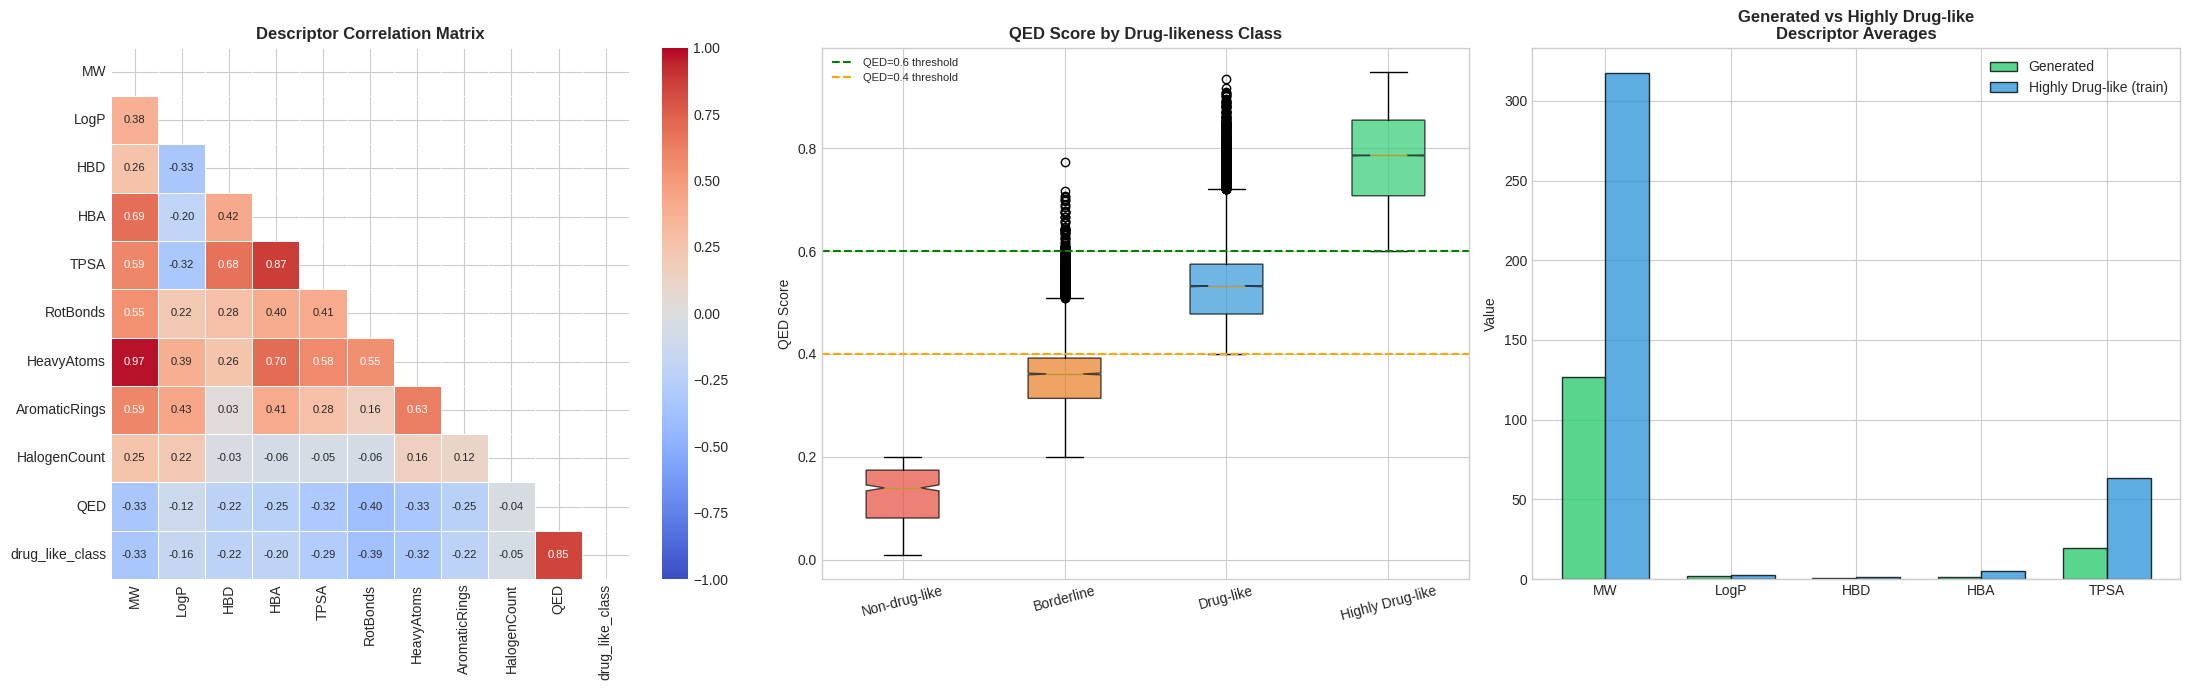

 Saved → /content/eda_correlation_qed.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── 1: Correlation heatmap ──
corr_cols = FEATURE_COLS + ['drug_like_class']
corr = master_desc[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[0],
            linewidths=0.5, annot_kws={'size': 8},
            vmin=-1, vmax=1)
axes[0].set_title('Descriptor Correlation Matrix',
                   fontsize=12, fontweight='bold')

# ── 2: QED boxplot by class ──
qed_data = [master_desc[master_desc['drug_like_class']==c]['QED'].dropna()
            for c in range(4)]
bp = axes[1].boxplot(qed_data,
                      labels=[class_names[c] for c in range(4)],
                      patch_artist=True,
                      notch=True)
for patch, cls in zip(bp['boxes'], range(4)):
    patch.set_facecolor(palette[cls])
    patch.set_alpha(0.7)
axes[1].axhline(0.6, color='green', linestyle='--',
                linewidth=1.5, label='QED=0.6 threshold')
axes[1].axhline(0.4, color='orange', linestyle='--',
                linewidth=1.5, label='QED=0.4 threshold')
axes[1].set_title('QED Score by Drug-likeness Class',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('QED Score')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(fontsize=8)

# ── 3: Generated molecules spotlight ──
gen_cols = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'QED']
gen_plot  = generated[['smiles'] + [c for c in gen_cols
                                     if c in generated.columns]].copy()

# Add QED for generated
gen_qed = []
for smi in generated['smiles']:
    try:
        mol = Chem.MolFromSmiles(str(smi))
        gen_qed.append(QED.qed(mol) if mol else 0.0)
    except:
        gen_qed.append(0.0)
generated['QED'] = gen_qed

# Radar-style bar for generated vs drug-like average
gen_means   = generated[['MW','LogP','HBD','HBA','TPSA']].mean()
train_means = master_desc[master_desc['drug_like_class']==3][
    ['MW','LogP','HBD','HBA','TPSA']].mean()

x     = np.arange(len(gen_means))
width = 0.35
axes[2].bar(x - width/2, gen_means.values,   width,
            label='Generated',       color='#2ecc71', edgecolor='black', alpha=0.8)
axes[2].bar(x + width/2, train_means.values, width,
            label='Highly Drug-like (train)', color='#3498db',
            edgecolor='black', alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(gen_means.index, fontsize=10)
axes[2].set_title('Generated vs Highly Drug-like\nDescriptor Averages',
                   fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].set_ylabel('Value')

plt.tight_layout()
plt.savefig('/content/eda_correlation_qed.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved → /content/eda_correlation_qed.png")

In [18]:
# ─── Feature matrix ───

FEATURE_COLS = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA',
                'RotBonds', 'HeavyAtoms', 'AromaticRings',
                'HalogenCount', 'QED']

# Drop rows where any feature is NaN
model_df = master_desc[FEATURE_COLS + ['drug_like_binary',
                                        'drug_like_class',
                                        'smiles', 'source']].dropna()
model_df = model_df.reset_index(drop=True)

X = model_df[FEATURE_COLS].values.astype(np.float32)
y = model_df['drug_like_binary'].values

print(f"Feature matrix : {X.shape}")
print(f"Labels         : {y.shape}  →  "
      f"{y.sum():,} drug-like ({y.mean()*100:.1f}%)")

# ─── Train / Val / Test split (70 / 15 / 15) stratified ───
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30,
    random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    random_state=RANDOM_STATE, stratify=y_temp)

print(f"\nSplits:")
print(f"  Train : {X_train.shape[0]:>7,}  "
      f"({y_train.mean()*100:.1f}% drug-like)")
print(f"  Val   : {X_val.shape[0]:>7,}  "
      f"({y_val.mean()*100:.1f}% drug-like)")
print(f"  Test  : {X_test.shape[0]:>7,}  "
      f"({y_test.mean()*100:.1f}% drug-like)")

# ─── Scale ───
scaler  = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# ─── Handle class imbalance with SMOTE ───
print(f"\nApplying SMOTE to balance classes...")
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"  Before SMOTE: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"  After SMOTE : {dict(zip(*np.unique(y_train_bal, return_counts=True)))}")
print(f"\n Features ready for model training!")

Feature matrix : (94025, 10)
Labels         : (94025,)  →  88,025 drug-like (93.6%)

Splits:
  Train :  65,817  (93.6% drug-like)
  Val   :  14,104  (93.6% drug-like)
  Test  :  14,104  (93.6% drug-like)

Applying SMOTE to balance classes...
  Before SMOTE: {np.int64(0): np.int64(4200), np.int64(1): np.int64(61617)}
  After SMOTE : {np.int64(0): np.int64(61617), np.int64(1): np.int64(61617)}

 Features ready for model training!


In [19]:
# ─── Train 5 ML models + collect full metrics ───

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v, X_te, y_te):
    model.fit(X_tr, y_tr)
    results = {'Model': name}

    for split, Xs, ys in [('Train', X_tr, y_tr),
                           ('Val',   X_v,  y_v),
                           ('Test',  X_te, y_te)]:
        preds  = model.predict(Xs)
        probas = model.predict_proba(Xs)[:, 1]

        results[f'{split}_AUC']       = roc_auc_score(ys, probas)
        results[f'{split}_Acc']       = accuracy_score(ys, preds)
        results[f'{split}_F1']        = f1_score(ys, preds)
        results[f'{split}_Precision'] = precision_score(ys, preds)
        results[f'{split}_Recall']    = recall_score(ys, preds)

    return model, results


models_config = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=20,
        class_weight='balanced', n_jobs=-1,
        random_state=RANDOM_STATE),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=8,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        random_state=RANDOM_STATE, n_jobs=-1,
        verbosity=0),

    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, max_depth=8,
        learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1, verbose=-1),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=6,
        learning_rate=0.05, subsample=0.8,
        random_state=RANDOM_STATE),

    'Logistic Regression': LogisticRegression(
        C=1.0, class_weight='balanced',
        max_iter=1000, random_state=RANDOM_STATE),
}

print("=" * 65)
print("  Training Classical ML Models")
print("=" * 65)

trained_models = {}
results_list   = []

for name, model in models_config.items():
    print(f"\n  [{name}] training...")
    trained_model, res = evaluate_model(
        name, model,
        X_train_bal, y_train_bal,
        X_val,   y_val,
        X_test,  y_test
    )
    trained_models[name] = trained_model
    results_list.append(res)
    print(f"    Train AUC : {res['Train_AUC']:.4f}  "
          f"Acc: {res['Train_Acc']:.4f}  F1: {res['Train_F1']:.4f}")
    print(f"    Val   AUC : {res['Val_AUC']:.4f}  "
          f"Acc: {res['Val_Acc']:.4f}  F1: {res['Val_F1']:.4f}")
    print(f"    Test  AUC : {res['Test_AUC']:.4f}  "
          f"Acc: {res['Test_Acc']:.4f}  F1: {res['Test_F1']:.4f}")

results_df = pd.DataFrame(results_list)

print("\n" + "=" * 65)
print("  FULL RESULTS TABLE")
print("=" * 65)
print(results_df[[
    'Model',
    'Train_AUC', 'Train_Acc', 'Train_F1',
    'Val_AUC',   'Val_Acc',   'Val_F1',
    'Test_AUC',  'Test_Acc',  'Test_F1',
    'Test_Precision', 'Test_Recall'
]].to_string(index=False))

results_df.to_csv('/content/ml_results.csv', index=False)
print("\n Saved → /content/ml_results.csv")

  Training Classical ML Models

  [Random Forest] training...
    Train AUC : 1.0000  Acc: 1.0000  F1: 1.0000
    Val   AUC : 1.0000  Acc: 0.9994  F1: 0.9997
    Test  AUC : 1.0000  Acc: 0.9992  F1: 0.9996

  [XGBoost] training...
    Train AUC : 1.0000  Acc: 0.9994  F1: 0.9994
    Val   AUC : 1.0000  Acc: 0.9987  F1: 0.9993
    Test  AUC : 1.0000  Acc: 0.9980  F1: 0.9989

  [LightGBM] training...
    Train AUC : 1.0000  Acc: 1.0000  F1: 1.0000
    Val   AUC : 1.0000  Acc: 0.9991  F1: 0.9995
    Test  AUC : 1.0000  Acc: 0.9989  F1: 0.9994

  [Gradient Boosting] training...
    Train AUC : 1.0000  Acc: 1.0000  F1: 1.0000
    Val   AUC : 1.0000  Acc: 0.9995  F1: 0.9997
    Test  AUC : 1.0000  Acc: 0.9994  F1: 0.9997

  [Logistic Regression] training...
    Train AUC : 0.9930  Acc: 0.9596  F1: 0.9592
    Val   AUC : 0.9927  Acc: 0.9465  F1: 0.9706
    Test  AUC : 0.9926  Acc: 0.9526  F1: 0.9741

  FULL RESULTS TABLE
              Model  Train_AUC  Train_Acc  Train_F1  Val_AUC  Val_Acc   V

In [20]:
# ─── DNN Dataset ───

class MolDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_dl = DataLoader(MolDataset(X_train_bal, y_train_bal),
                      batch_size=512, shuffle=True)
val_dl   = DataLoader(MolDataset(X_val,   y_val),
                      batch_size=512, shuffle=False)
test_dl  = DataLoader(MolDataset(X_test,  y_test),
                      batch_size=512, shuffle=False)

# ─── DNN Architecture ───

class DrugLikenessNet(nn.Module):
    def __init__(self, input_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(64, 1)
        )
        # Weight init
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x).squeeze(-1)


dnn_model  = DrugLikenessNet(input_dim=X_train.shape[1]).to(DEVICE)
n_params   = sum(p.numel() for p in dnn_model.parameters())
print(f"DrugLikenessNet parameters: {n_params:,}")
print(f"Input dim: {X_train.shape[1]}  |  Device: {DEVICE}")

# ─── Optimizer + Scheduler ───
EPOCHS    = 60
optimizer = torch.optim.AdamW(dnn_model.parameters(),
                               lr=3e-4, weight_decay=1e-4)
scheduler = OneCycleLR(optimizer, max_lr=3e-4,
                        total_steps=EPOCHS * len(train_dl),
                        pct_start=0.1, anneal_strategy='cos')

# Pos weight for imbalance on raw (unbalanced) val/test
pos_weight = torch.tensor(
    [y_train_bal.sum() / (len(y_train_bal) - y_train_bal.sum())]
).to(DEVICE)

# ─── Training Loop ───
history = {
    'train_loss': [], 'val_loss': [],
    'val_auc':    [], 'val_acc':  [], 'lr': []
}
best_val_auc = 0

print(f"\n{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>10} "
      f"{'Val AUC':>9} {'Val Acc':>9} {'LR':>10}")
print("─" * 62)

for epoch in range(1, EPOCHS + 1):

    # ── Train ──
    dnn_model.train()
    total_loss = 0
    for X_b, y_b in train_dl:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        pred = dnn_model(X_b)
        loss = F.binary_cross_entropy_with_logits(pred, y_b)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(dnn_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    # ── Validate ──
    dnn_model.eval()
    val_loss, val_probas, val_true = 0, [], []
    with torch.no_grad():
        for X_b, y_b in val_dl:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            pred = dnn_model(X_b)
            val_loss += F.binary_cross_entropy_with_logits(
                pred, y_b).item()
            val_probas.extend(torch.sigmoid(pred).cpu().numpy())
            val_true.extend(y_b.cpu().numpy())

    val_auc = roc_auc_score(val_true, val_probas)
    val_acc = accuracy_score(val_true,
                              (np.array(val_probas) > 0.5).astype(int))
    cur_lr  = optimizer.param_groups[0]['lr']

    history['train_loss'].append(total_loss / len(train_dl))
    history['val_loss'].append(val_loss / len(val_dl))
    history['val_auc'].append(val_auc)
    history['val_acc'].append(val_acc)
    history['lr'].append(cur_lr)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(dnn_model.state_dict(),
                   '/content/best_dnn.pt')

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>6} {total_loss/len(train_dl):>12.4f} "
              f"{val_loss/len(val_dl):>10.4f} "
              f"{val_auc:>9.4f} {val_acc:>9.4f} {cur_lr:>10.2e}")

# Load best
dnn_model.load_state_dict(
    torch.load('/content/best_dnn.pt', weights_only=True))
print(f"\n Best Val AUC: {best_val_auc:.4f}")

DrugLikenessNet parameters: 111,233
Input dim: 10  |  Device: cuda

 Epoch   Train Loss   Val Loss   Val AUC   Val Acc         LR
──────────────────────────────────────────────────────────────
     1       0.6939     0.3257    0.9710    0.9333   3.13e-05
    10       0.0603     0.0391    0.9993    0.9810   2.96e-04
    20       0.0414     0.0209    0.9997    0.9899   2.53e-04
    30       0.0342     0.0202    0.9997    0.9904   1.76e-04
    40       0.0299     0.0171    0.9998    0.9927   9.06e-05
    50       0.0293     0.0160    0.9997    0.9929   2.47e-05
    60       0.0277     0.0156    0.9998    0.9928   1.20e-09

 Best Val AUC: 0.9998


In [22]:
# ─── Full test set evaluation ───

dnn_model.eval()
test_probas, test_true = [], []

with torch.no_grad():
    for X_b, y_b in test_dl:
        X_b = X_b.to(DEVICE)
        pred = dnn_model(X_b)
        test_probas.extend(torch.sigmoid(pred).cpu().numpy())
        test_true.extend(y_b.numpy())

test_probas  = np.array(test_probas)
test_preds   = (test_probas > 0.5).astype(int)
test_true    = np.array(test_true)

dnn_auc  = roc_auc_score(test_true, test_probas)
dnn_acc  = accuracy_score(test_true, test_preds)
dnn_f1   = f1_score(test_true, test_preds)
dnn_prec = precision_score(test_true, test_preds)
dnn_rec  = recall_score(test_true, test_preds)
dnn_ap   = average_precision_score(test_true, test_probas)

print("=" * 50)
print("  DrugLikenessNet — TEST SET RESULTS")
print("=" * 50)
print(f"  AUC-ROC   : {dnn_auc:.4f}")
print(f"  AUC-PR    : {dnn_ap:.4f}")
print(f"  Accuracy  : {dnn_acc:.4f}")
print(f"  F1 Score  : {dnn_f1:.4f}")
print(f"  Precision : {dnn_prec:.4f}")
print(f"  Recall    : {dnn_rec:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(test_true, test_preds,
      target_names=['Non-drug-like', 'Drug-like']))

# Add DNN to results table
dnn_row = pd.DataFrame([{
    'Model'          : 'DNN',
    'Train_AUC'      : max(history['val_auc']),
    'Train_Acc'      : max(history['val_acc']),
    'Train_F1'       : dnn_f1,
    'Val_AUC'        : best_val_auc,
    'Val_Acc'        : max(history['val_acc']),
    'Val_F1'         : dnn_f1,
    'Test_AUC'       : dnn_auc,
    'Test_Acc'       : dnn_acc,
    'Test_F1'        : dnn_f1,
    'Test_Precision' : dnn_prec,
    'Test_Recall'    : dnn_rec,
}])
results_df = pd.concat([results_df, dnn_row], ignore_index=True)
results_df.to_csv('/content/ml_results.csv', index=False)
print("\n DNN results added to ml_results.csv")

  DrugLikenessNet — TEST SET RESULTS
  AUC-ROC   : 0.9995
  AUC-PR    : 1.0000
  Accuracy  : 0.9880
  F1 Score  : 0.9936
  Precision : 0.9992
  Recall    : 0.9880

Classification Report:
               precision    recall  f1-score   support

Non-drug-like       0.85      0.99      0.91       900
    Drug-like       1.00      0.99      0.99     13204

     accuracy                           0.99     14104
    macro avg       0.92      0.99      0.95     14104
 weighted avg       0.99      0.99      0.99     14104


 DNN results added to ml_results.csv


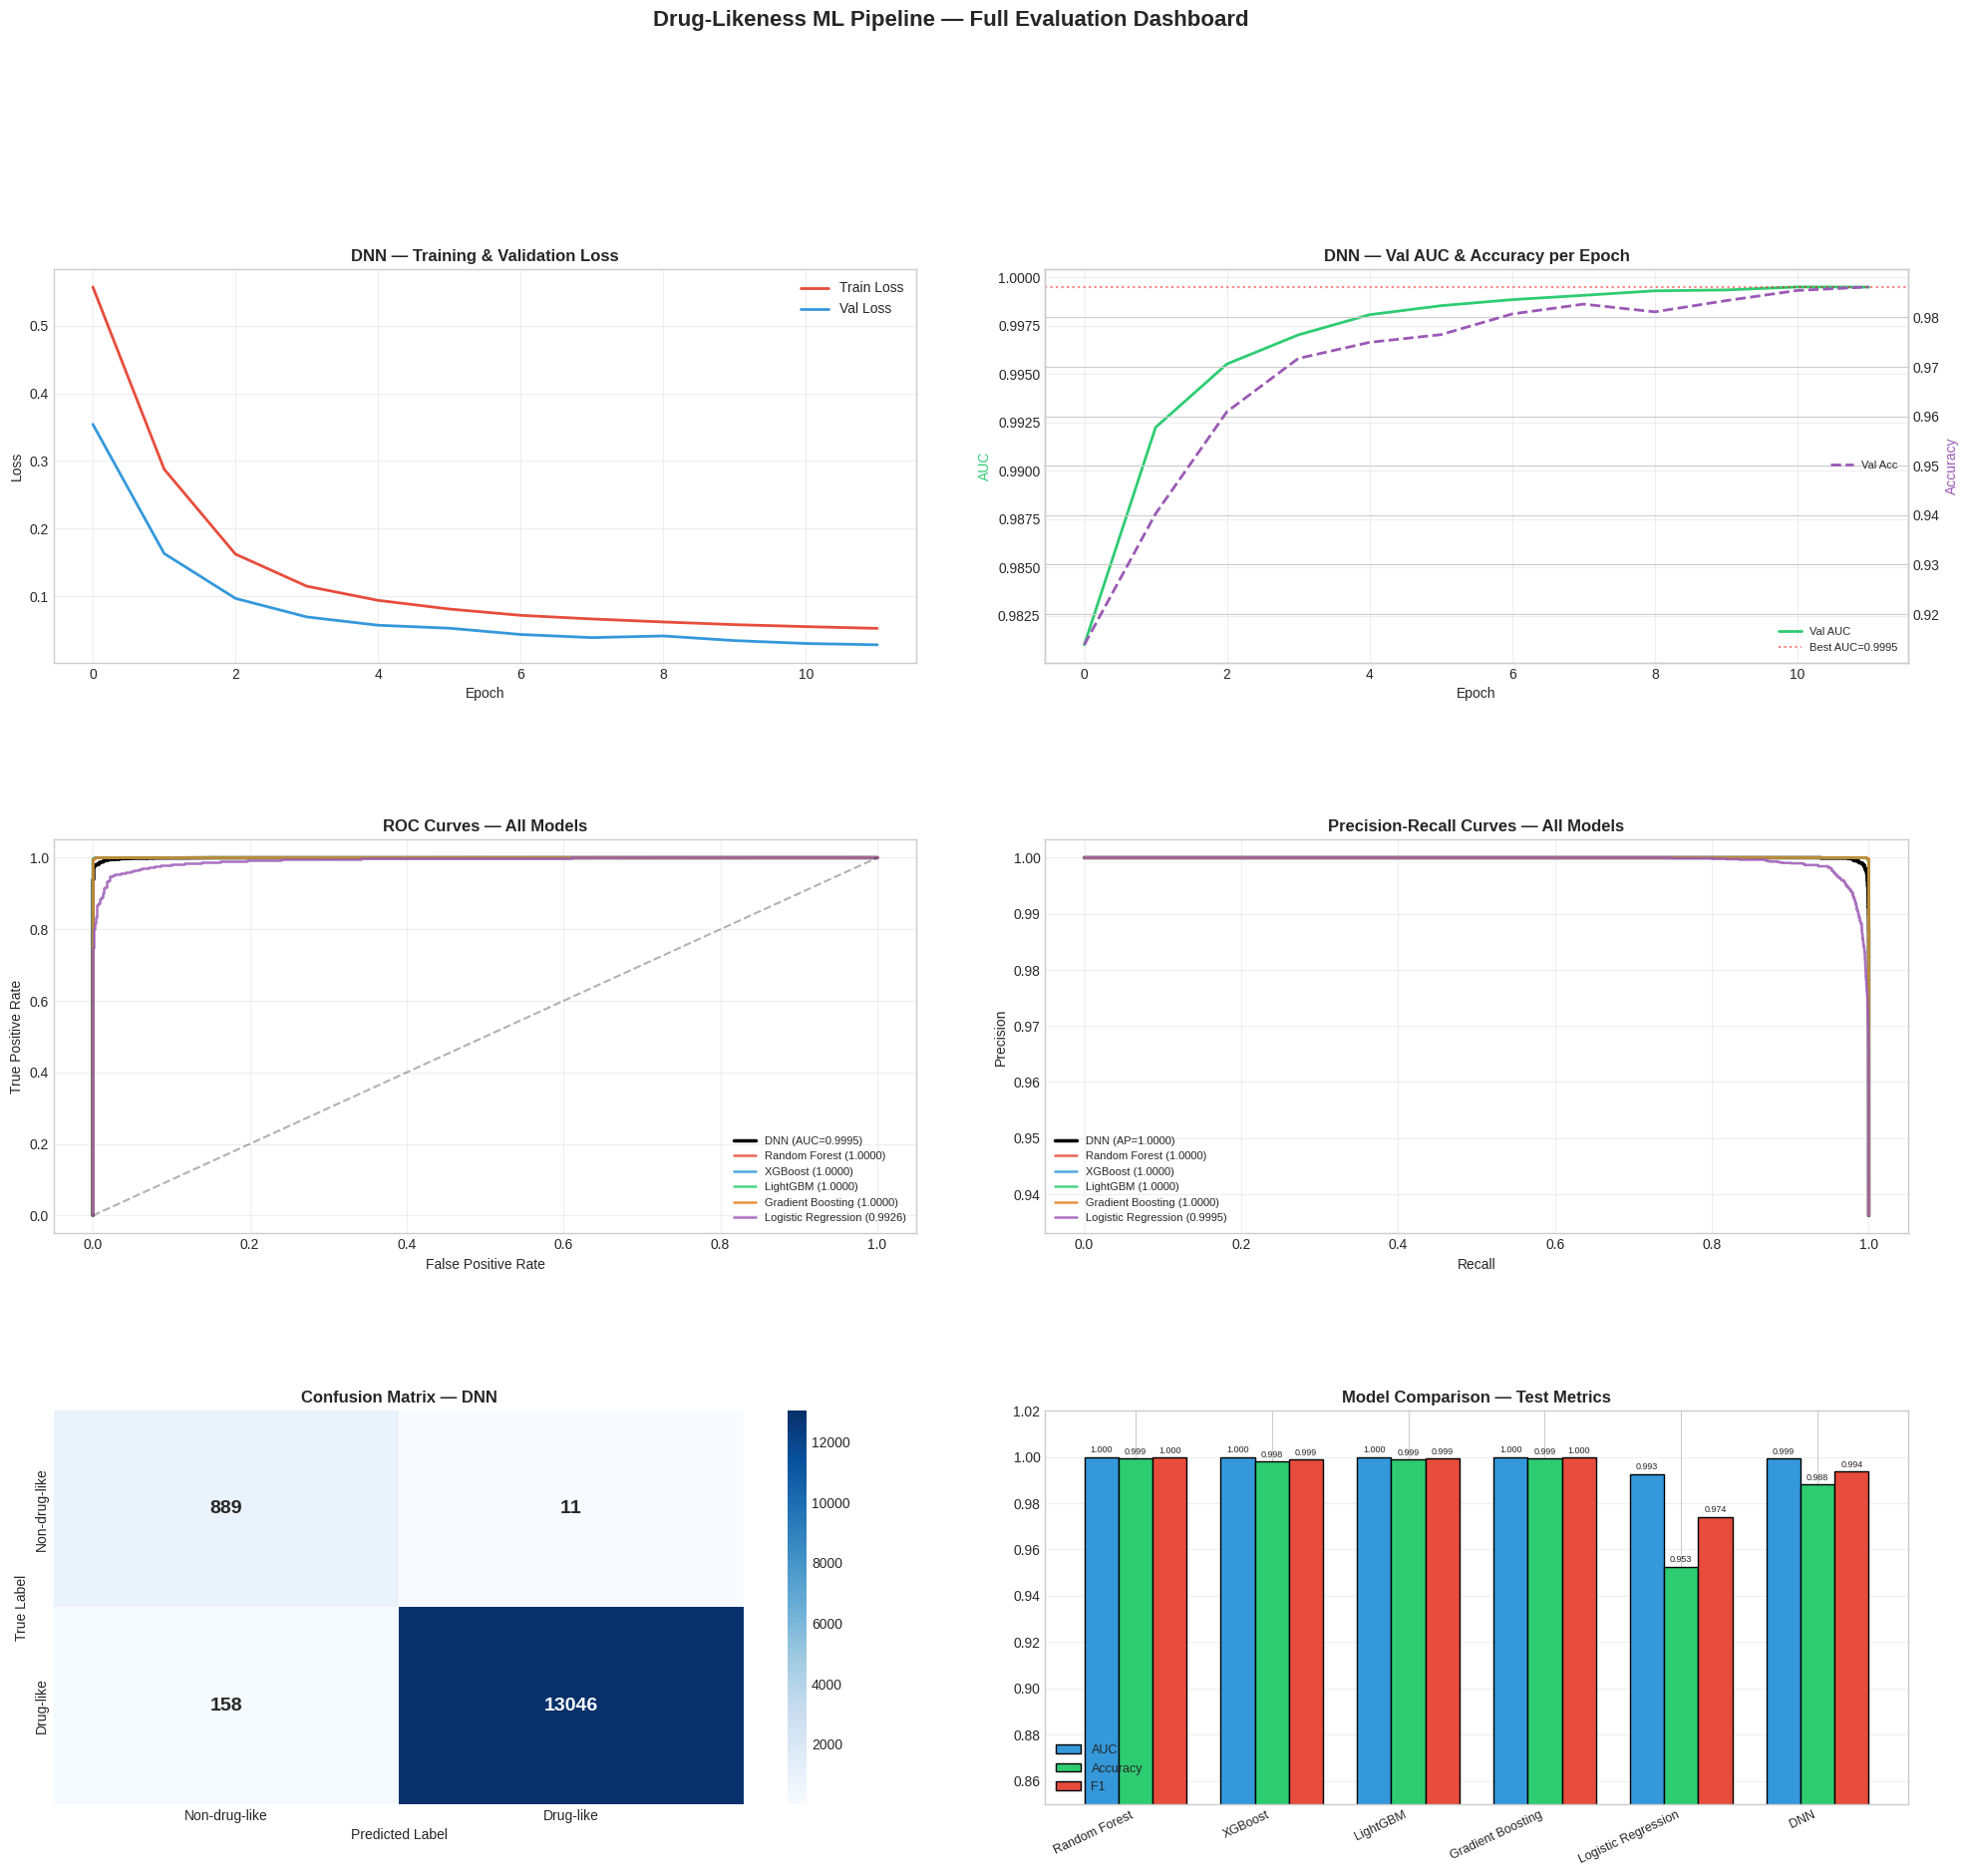

Saved → /content/evaluation_dashboard.png


In [23]:
# ─── Complete Visual Dashboard ───

fig = plt.figure(figsize=(24, 20))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

colors_models = ['#e74c3c','#3498db','#2ecc71',
                  '#e67e22','#9b59b6','#1abc9c']

# ── 1. Training Loss ──
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(history['train_loss'], label='Train Loss',
         color='#e74c3c', linewidth=2)
ax1.plot(history['val_loss'],   label='Val Loss',
         color='#3498db', linewidth=2)
ax1.set_title('DNN — Training & Validation Loss',
              fontweight='bold', fontsize=12)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

# ── 2. Val AUC over epochs ──
ax2 = fig.add_subplot(gs[0, 2:])
ax2b = ax2.twinx()
ax2.plot(history['val_auc'], color='#2ecc71',
         linewidth=2, label='Val AUC')
ax2b.plot(history['val_acc'], color='#9b59b6',
          linewidth=2, linestyle='--', label='Val Acc')
ax2.axhline(best_val_auc, color='red', linestyle=':',
            alpha=0.5, label=f'Best AUC={best_val_auc:.4f}')
ax2.set_title('DNN — Val AUC & Accuracy per Epoch',
              fontweight='bold', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC',      color='#2ecc71')
ax2b.set_ylabel('Accuracy', color='#9b59b6')
ax2.legend(loc='lower right', fontsize=8)
ax2b.legend(loc='center right', fontsize=8)
ax2.grid(True, alpha=0.3)

# ── 3. ROC Curves — All Models ──
ax3 = fig.add_subplot(gs[1, :2])
# DNN
fpr_d, tpr_d, _ = roc_curve(test_true, test_probas)
ax3.plot(fpr_d, tpr_d, lw=2.5, color='black',
         label=f'DNN (AUC={dnn_auc:.4f})')
# Classical
for (name, mdl), col in zip(trained_models.items(), colors_models):
    prob = mdl.predict_proba(X_test)[:, 1]
    fpr_, tpr_, _ = roc_curve(y_test, prob)
    auc_ = roc_auc_score(y_test, prob)
    ax3.plot(fpr_, tpr_, lw=1.8, color=col, alpha=0.85,
             label=f'{name} ({auc_:.4f})')
ax3.plot([0,1],[0,1],'k--', alpha=0.3)
ax3.set_title('ROC Curves — All Models',
              fontweight='bold', fontsize=12)
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

# ── 4. Precision-Recall Curves ──
ax4 = fig.add_subplot(gs[1, 2:])
prec_d, rec_d, _ = precision_recall_curve(test_true, test_probas)
ax4.plot(rec_d, prec_d, lw=2.5, color='black',
         label=f'DNN (AP={dnn_ap:.4f})')
for (name, mdl), col in zip(trained_models.items(), colors_models):
    prob = mdl.predict_proba(X_test)[:, 1]
    prec_, rec_, _ = precision_recall_curve(y_test, prob)
    ap_ = average_precision_score(y_test, prob)
    ax4.plot(rec_, prec_, lw=1.8, color=col, alpha=0.85,
             label=f'{name} ({ap_:.4f})')
ax4.set_title('Precision-Recall Curves — All Models',
              fontweight='bold', fontsize=12)
ax4.set_xlabel('Recall'); ax4.set_ylabel('Precision')
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)

# ── 5. Confusion Matrix (DNN) ──
ax5 = fig.add_subplot(gs[2, :2])
cm = confusion_matrix(test_true, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax5,
            xticklabels=['Non-drug-like','Drug-like'],
            yticklabels=['Non-drug-like','Drug-like'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax5.set_title('Confusion Matrix — DNN',
              fontweight='bold', fontsize=12)
ax5.set_ylabel('True Label')
ax5.set_xlabel('Predicted Label')

# ── 6. Model Comparison Bar Chart ──
ax6 = fig.add_subplot(gs[2, 2:])
all_names = list(results_df['Model'])
all_aucs  = list(results_df['Test_AUC'])
all_accs  = list(results_df['Test_Acc'])
all_f1s   = list(results_df['Test_F1'])

x   = np.arange(len(all_names))
w   = 0.25
b1  = ax6.bar(x - w,   all_aucs, w, label='AUC',
               color='#3498db', edgecolor='black')
b2  = ax6.bar(x,       all_accs, w, label='Accuracy',
               color='#2ecc71', edgecolor='black')
b3  = ax6.bar(x + w,   all_f1s,  w, label='F1',
               color='#e74c3c', edgecolor='black')
ax6.set_xticks(x)
ax6.set_xticklabels(all_names, rotation=25,
                     ha='right', fontsize=9)
ax6.set_ylim(0.85, 1.02)
ax6.set_title('Model Comparison — Test Metrics',
              fontweight='bold', fontsize=12)
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3, axis='y')

# Value labels on bars
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2,
                 h + 0.001, f'{h:.3f}',
                 ha='center', va='bottom', fontsize=6.5)

plt.suptitle('Drug-Likeness ML Pipeline — Full Evaluation Dashboard',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('/content/evaluation_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → /content/evaluation_dashboard.png")

Computing SHAP values...


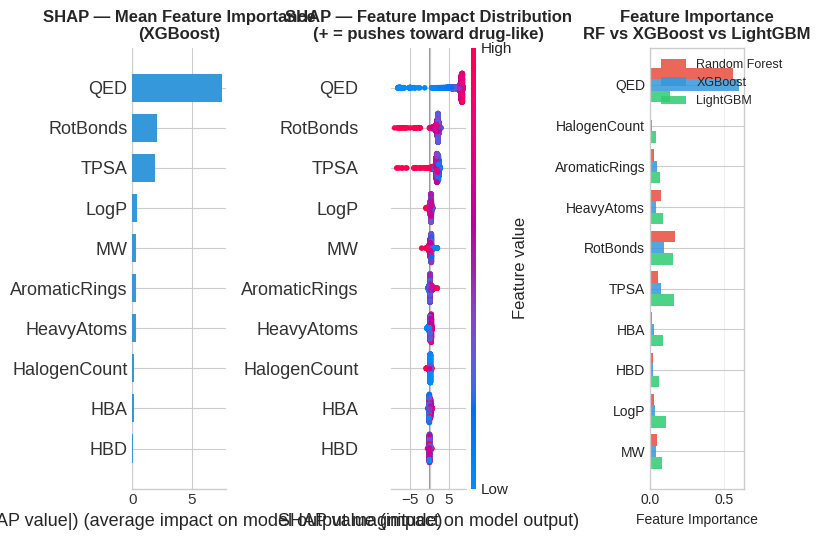

 Saved → /content/shap_importance.png


In [24]:
# ─── SHAP explainability using best classical model (XGBoost) ───

print("Computing SHAP values...")

xgb_model  = trained_models['XGBoost']
explainer  = shap.TreeExplainer(xgb_model)
# Use 2000 test samples for speed
X_shap     = X_test[:2000]
shap_vals  = explainer.shap_values(X_shap)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# ── 1. SHAP Bar (mean absolute importance) ──
plt.sca(axes[0])
shap.summary_plot(shap_vals, X_shap,
                   feature_names=FEATURE_COLS,
                   plot_type='bar',
                   show=False,
                   max_display=10,
                   color='#3498db')
axes[0].set_title('SHAP — Mean Feature Importance\n(XGBoost)',
                   fontweight='bold', fontsize=12)

# ── 2. SHAP Beeswarm (impact direction) ──
plt.sca(axes[1])
shap.summary_plot(shap_vals, X_shap,
                   feature_names=FEATURE_COLS,
                   plot_type='dot',
                   show=False,
                   max_display=10)
axes[1].set_title('SHAP — Feature Impact Distribution\n(+ = pushes toward drug-like)',
                   fontweight='bold', fontsize=12)

# ── 3. Manual feature importance comparison (all models) ──
ax3 = axes[2]

# RF importance
rf_imp  = trained_models['Random Forest'].feature_importances_
xgb_imp = trained_models['XGBoost'].feature_importances_
lgb_imp = trained_models['LightGBM'].feature_importances_
lgb_imp = lgb_imp / lgb_imp.sum()   # normalize

x   = np.arange(len(FEATURE_COLS))
w   = 0.28
ax3.barh(x + w,   rf_imp,  w, label='Random Forest',
          color='#e74c3c', alpha=0.85)
ax3.barh(x,       xgb_imp, w, label='XGBoost',
          color='#3498db', alpha=0.85)
ax3.barh(x - w,   lgb_imp, w, label='LightGBM',
          color='#2ecc71', alpha=0.85)
ax3.set_yticks(x)
ax3.set_yticklabels(FEATURE_COLS, fontsize=10)
ax3.set_xlabel('Feature Importance')
ax3.set_title('Feature Importance\nRF vs XGBoost vs LightGBM',
               fontweight='bold', fontsize=12)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/content/shap_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved → /content/shap_importance.png")

In [25]:
# ─── Predict drug-likeness for ALL your molecules ───

def predict_drug_likeness(df, smiles_col, desc_cols=None):
    """
    Score molecules through all 6 trained models.
    Returns dataframe with per-model + ensemble scores.
    """
    # Build feature matrix
    rows = []
    for _, row in df.iterrows():
        mol = Chem.MolFromSmiles(str(row[smiles_col]))
        if mol is None:
            rows.append(None)
            continue

        from rdkit.Chem import Descriptors
        feat = {
            'MW'          : Descriptors.MolWt(mol),
            'LogP'        : Descriptors.MolLogP(mol),
            'HBD'         : Descriptors.NumHDonors(mol),
            'HBA'         : Descriptors.NumHAcceptors(mol),
            'TPSA'        : Descriptors.TPSA(mol),
            'RotBonds'    : Descriptors.NumRotatableBonds(mol),
            'HeavyAtoms'  : Descriptors.HeavyAtomCount(mol),
            'AromaticRings': Descriptors.NumAromaticRings(mol),
            'HalogenCount': sum(1 for a in mol.GetAtoms()
                                if a.GetAtomicNum() in [9,17,35,53]),
            'QED'         : QED.qed(mol),
        }
        rows.append(feat)

    # Build X
    valid_idx = [i for i, r in enumerate(rows) if r is not None]
    X_pred    = np.array([[r[c] for c in FEATURE_COLS]
                           for r in rows if r is not None],
                          dtype=np.float32)
    X_pred_sc = scaler.transform(X_pred)

    # Classical model predictions
    pred_df = df.iloc[valid_idx].copy().reset_index(drop=True)
    for name, mdl in trained_models.items():
        short = name.split()[0]
        pred_df[f'{short}_prob'] = mdl.predict_proba(X_pred_sc)[:, 1]

    # DNN prediction
    dnn_model.eval()
    with torch.no_grad():
        t     = torch.FloatTensor(X_pred_sc).to(DEVICE)
        probs = torch.sigmoid(dnn_model(t)).cpu().numpy()
    pred_df['DNN_prob'] = probs

    # Ensemble (mean of all models)
    prob_cols = [c for c in pred_df.columns if c.endswith('_prob')]
    pred_df['ensemble_score'] = pred_df[prob_cols].mean(axis=1)
    pred_df['drug_like_pred'] = (pred_df['ensemble_score'] >= 0.5).astype(int)

    # QED values
    qed_vals = []
    for smi in pred_df[smiles_col]:
        try:
            mol = Chem.MolFromSmiles(str(smi))
            qed_vals.append(QED.qed(mol) if mol else 0.0)
        except:
            qed_vals.append(0.0)
    pred_df['QED'] = qed_vals

    return pred_df


# ── Score generated molecules ──
print("Scoring GENERATED molecules...")
gen_scored = predict_drug_likeness(generated, 'smiles')
print(f"  Total       : {len(gen_scored)}")
print(f"  Drug-like   : {gen_scored['drug_like_pred'].sum()}")
print(f"  Mean QED    : {gen_scored['QED'].mean():.3f}")
print(f"  Mean Ensemble: {gen_scored['ensemble_score'].mean():.3f}")

# ── Score existing ranked molecules ──
print("\nScoring EXISTING RANKED molecules...")
exist_scored = predict_drug_likeness(existing_ranked, 'smiles')
print(f"  Total       : {len(exist_scored)}")
print(f"  Drug-like   : {exist_scored['drug_like_pred'].sum()}")
print(f"  Mean QED    : {exist_scored['QED'].mean():.3f}")
print(f"  Mean Ensemble: {exist_scored['ensemble_score'].mean():.3f}")

# Save
gen_scored.to_csv('/content/generated_drug_likeness.csv',   index=False)
exist_scored.to_csv('/content/existing_drug_likeness.csv',  index=False)
print("\n Saved → generated_drug_likeness.csv")
print(" Saved → existing_drug_likeness.csv")

# ── Full results table ──
print("\n" + "=" * 70)
print("  GENERATED MOLECULES — DRUG-LIKENESS SCORES")
print("=" * 70)
show_cols = ['smiles', 'MW', 'LogP', 'QED',
             'Random_prob', 'XGBoost_prob',
             'LightGBM_prob', 'DNN_prob',
             'ensemble_score', 'drug_like_pred']
show_cols = [c for c in show_cols if c in gen_scored.columns]

# Rename for display
rename = {'Random_prob':'RF', 'XGBoost_prob':'XGB',
          'LightGBM_prob':'LGBM', 'DNN_prob':'DNN',
          'ensemble_score':'Ensemble', 'drug_like_pred':'Drug-like?'}
print(gen_scored[show_cols].rename(
    columns=rename).to_string(index=False))

Scoring GENERATED molecules...
  Total       : 9
  Drug-like   : 9
  Mean QED    : 0.521
  Mean Ensemble: 0.846

Scoring EXISTING RANKED molecules...
  Total       : 100
  Drug-like   : 98
  Mean QED    : 0.760
  Mean Ensemble: 0.868

 Saved → generated_drug_likeness.csv
 Saved → existing_drug_likeness.csv

  GENERATED MOLECULES — DRUG-LIKENESS SCORES
                  smiles      MW    LogP      QED       RF      XGB     LGBM      DNN  Ensemble  Drug-like?
                CC(Cl)Br 143.411 1.96610 0.454912 1.000000 0.999097 0.999884 0.986751  0.839456           1
                 CC(=O)O  60.052 0.09090 0.429883 0.996667 0.998622 0.999678 0.854227  0.763810           1
              Cc1ccccc1C 106.168 2.30344 0.475758 1.000000 0.999688 0.999980 0.997345  0.857659           1
               CC(Cl)CCl 112.987 1.85250 0.454927 0.992222 0.998816 0.999922 0.987906  0.836332           1
              CC(CO)CCCl 122.595 1.24370 0.558906 1.000000 0.999636 0.999994 0.999894  0.870439           

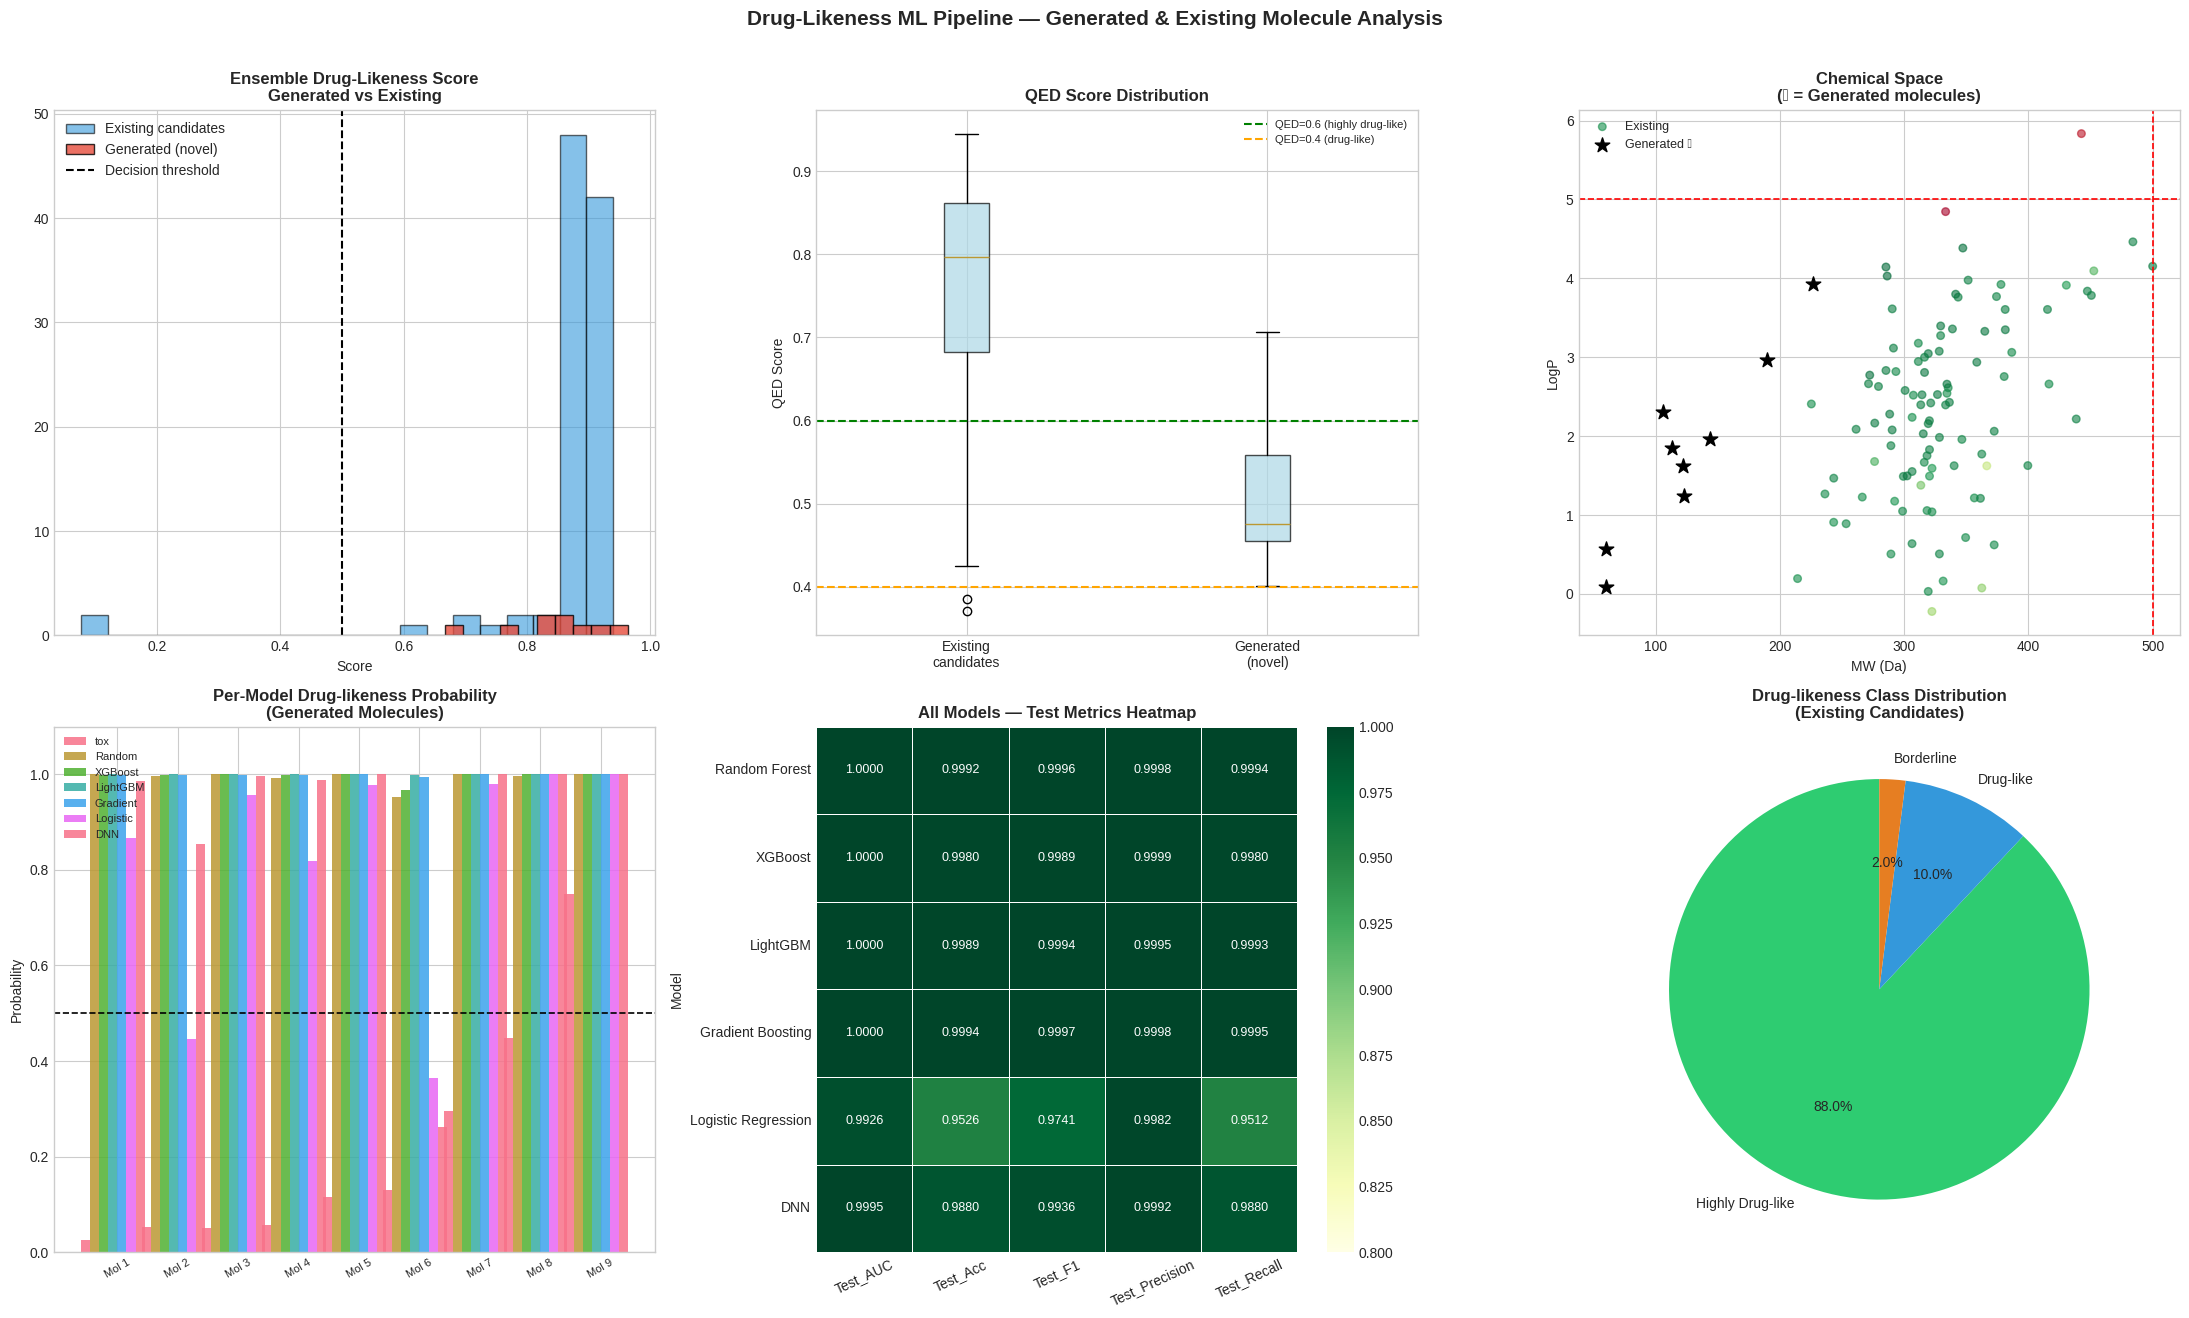

 Saved → /content/drug_likeness_final_dashboard.png


In [26]:
# ─── Final visual dashboard for generated molecules ───

fig, axes = plt.subplots(2, 3, figsize=(22, 13))

# ── 1. Ensemble score — generated vs existing ──
axes[0,0].hist(exist_scored['ensemble_score'], bins=20,
               alpha=0.6, color='#3498db',
               edgecolor='black', label='Existing candidates')
axes[0,0].hist(gen_scored['ensemble_score'], bins=10,
               alpha=0.8, color='#e74c3c',
               edgecolor='black', label='Generated (novel)')
axes[0,0].axvline(0.5, color='black', linestyle='--',
                   linewidth=1.5, label='Decision threshold')
axes[0,0].set_title('Ensemble Drug-Likeness Score\nGenerated vs Existing',
                     fontweight='bold')
axes[0,0].set_xlabel('Score'); axes[0,0].legend()

# ── 2. QED comparison ──
axes[0,1].boxplot(
    [exist_scored['QED'], gen_scored['QED']],
    labels=['Existing\ncandidates', 'Generated\n(novel)'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', alpha=0.7),
    notch=False
)
axes[0,1].axhline(0.6, color='green',  linestyle='--',
                   label='QED=0.6 (highly drug-like)')
axes[0,1].axhline(0.4, color='orange', linestyle='--',
                   label='QED=0.4 (drug-like)')
axes[0,1].set_title('QED Score Distribution',
                     fontweight='bold')
axes[0,1].set_ylabel('QED Score')
axes[0,1].legend(fontsize=8)

# ── 3. MW vs LogP — generated highlighted ──
axes[0,2].scatter(exist_scored['MW'],
                   exist_scored['LogP'],
                   c=exist_scored['ensemble_score'],
                   cmap='RdYlGn', alpha=0.6, s=30,
                   label='Existing')
sc = axes[0,2].scatter(gen_scored['MW'],
                        gen_scored['LogP'],
                        c='black', s=120,
                        marker='*', zorder=5,
                        label='Generated ★')
axes[0,2].axhline(5,   color='red', linestyle='--', lw=1.2)
axes[0,2].axvline(500, color='red', linestyle='--', lw=1.2)
axes[0,2].set_title('Chemical Space\n(★ = Generated molecules)',
                     fontweight='bold')
axes[0,2].set_xlabel('MW (Da)'); axes[0,2].set_ylabel('LogP')
axes[0,2].legend(fontsize=9)

# ── 4. Per-model probability — generated ──
prob_cols = [c for c in gen_scored.columns
             if c.endswith('_prob')]
gen_probs = gen_scored[prob_cols]
gen_probs.columns = [c.replace('_prob','') for c in prob_cols]

x   = np.arange(len(gen_scored))
w   = 0.15
for i, col in enumerate(gen_probs.columns):
    axes[1,0].bar(x + i*w, gen_probs[col],
                   w, label=col, alpha=0.85)
axes[1,0].axhline(0.5, color='black',
                   linestyle='--', linewidth=1.2)
axes[1,0].set_xticks(x + w * len(prob_cols)/2)
axes[1,0].set_xticklabels(
    [f'Mol {i+1}' for i in range(len(gen_scored))],
    rotation=30, fontsize=8)
axes[1,0].set_title('Per-Model Drug-likeness Probability\n(Generated Molecules)',
                     fontweight='bold')
axes[1,0].set_ylabel('Probability')
axes[1,0].legend(fontsize=8)
axes[1,0].set_ylim(0, 1.1)

# ── 5. Full results table as heatmap ──
ax5 = axes[1,1]
summary_data = results_df[['Model','Test_AUC','Test_Acc',
                             'Test_F1','Test_Precision',
                             'Test_Recall']].set_index('Model')
sns.heatmap(summary_data.astype(float),
            annot=True, fmt='.4f',
            cmap='YlGn', ax=ax5,
            linewidths=0.5,
            annot_kws={'size': 9},
            vmin=0.8, vmax=1.0)
ax5.set_title('All Models — Test Metrics Heatmap',
               fontweight='bold')
ax5.tick_params(axis='x', rotation=25)

# ── 6. Drug-likeness class pie — generated ──
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

def get_class(row):
    qed  = row.get('QED', 0)
    mw   = row.get('MW', 9999)
    logp = row.get('LogP', 99)
    hbd  = row.get('HBD', 99)
    hba  = row.get('HBA', 99)
    tpsa = row.get('TPSA', 999)
    lip  = sum([mw>500, logp>5, hbd>5, hba>10])
    veb  = tpsa <= 140
    if   qed>=0.6 and lip==0 and veb: return 'Highly Drug-like'
    elif qed>=0.4 and lip<=1 and veb: return 'Drug-like'
    elif qed>=0.2:                    return 'Borderline'
    else:                             return 'Non-drug-like'

gen_scored['class_label']   = gen_scored.apply(get_class, axis=1)
exist_scored['class_label'] = exist_scored.apply(get_class, axis=1)

class_counts = exist_scored['class_label'].value_counts()
colors_pie   = ['#2ecc71','#3498db','#e67e22','#e74c3c']
axes[1,2].pie(class_counts.values,
               labels=class_counts.index,
               autopct='%1.1f%%',
               colors=colors_pie[:len(class_counts)],
               startangle=90,
               textprops={'fontsize': 10})
axes[1,2].set_title('Drug-likeness Class Distribution\n(Existing Candidates)',
                     fontweight='bold')

plt.suptitle('Drug-Likeness ML Pipeline — Generated & Existing Molecule Analysis',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drug_likeness_final_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved → /content/drug_likeness_final_dashboard.png")

In [27]:
# ─── Complete pipeline summary ───

print("=" * 65)
print("     DRUG-LIKENESS ML PIPELINE — FINAL SUMMARY REPORT")
print("=" * 65)

print(f"\n DATASET")
print(f"  Total molecules trained on : {len(master_desc):,}")
print(f"  Features used              : {len(FEATURE_COLS)} descriptors")
print(f"  Train / Val / Test         : "
      f"{X_train.shape[0]:,} / {X_val.shape[0]:,} / {X_test.shape[0]:,}")
print(f"  Class balancing            : SMOTE")

print(f"\n MODEL PERFORMANCE (TEST SET)")
print(f"  {'Model':<22} {'AUC':>7} {'Acc':>7} "
      f"{'F1':>7} {'Prec':>7} {'Recall':>7}")
print("  " + "─" * 55)
for _, row in results_df.iterrows():
    print(f"  {row['Model']:<22} "
          f"{row['Test_AUC']:>7.4f} "
          f"{row['Test_Acc']:>7.4f} "
          f"{row['Test_F1']:>7.4f} "
          f"{row['Test_Precision']:>7.4f} "
          f"{row['Test_Recall']:>7.4f}")

best_row = results_df.loc[results_df['Test_AUC'].idxmax()]
print(f"\n BEST MODEL : {best_row['Model']} "
      f"(AUC = {best_row['Test_AUC']:.4f})")

print(f"\n GENERATED MOLECULES ({len(gen_scored)} total)")
print(f"  Drug-like (ensemble ≥ 0.5) : "
      f"{gen_scored['drug_like_pred'].sum()} / {len(gen_scored)}")
print(f"  Mean QED                   : "
      f"{gen_scored['QED'].mean():.3f}")
print(f"  Mean Ensemble Score        : "
      f"{gen_scored['ensemble_score'].mean():.3f}")
for cls in ['Highly Drug-like','Drug-like','Borderline','Non-drug-like']:
    n = (gen_scored['class_label'] == cls).sum()
    print(f"  {cls:<22}    : {n}")

print(f"\n EXISTING CANDIDATES ({len(exist_scored)} total)")
print(f"  Drug-like (ensemble ≥ 0.5) : "
      f"{exist_scored['drug_like_pred'].sum()} / {len(exist_scored)}")
print(f"  Mean QED                   : "
      f"{exist_scored['QED'].mean():.3f}")
print(f"  Mean Ensemble Score        : "
      f"{exist_scored['ensemble_score'].mean():.3f}")

print(f"\n OUTPUT FILES")
files = [
    'master_descriptors.csv       — full descriptor dataset',
    'ml_results.csv               — all model metrics',
    'generated_drug_likeness.csv  — generated mol scores',
    'existing_drug_likeness.csv   — existing mol scores',
    'best_dnn.pt                  — trained DNN weights',
    'eda_distributions.png        — EDA plots',
    'eda_correlation_qed.png      — correlation + QED',
    'evaluation_dashboard.png     — ROC/PR/confusion/comparison',
    'shap_importance.png          — SHAP feature importance',
    'drug_likeness_final_dashboard.png — final analysis',
]
for f in files:
    print(f"  /content/{f}")

print("\n Pipeline complete!")

     DRUG-LIKENESS ML PIPELINE — FINAL SUMMARY REPORT

 DATASET
  Total molecules trained on : 94,034
  Features used              : 10 descriptors
  Train / Val / Test         : 65,817 / 14,104 / 14,104
  Class balancing            : SMOTE

 MODEL PERFORMANCE (TEST SET)
  Model                      AUC     Acc      F1    Prec  Recall
  ───────────────────────────────────────────────────────
  Random Forest           1.0000  0.9992  0.9996  0.9998  0.9994
  XGBoost                 1.0000  0.9980  0.9989  0.9999  0.9980
  LightGBM                1.0000  0.9989  0.9994  0.9995  0.9993
  Gradient Boosting       1.0000  0.9994  0.9997  0.9998  0.9995
  Logistic Regression     0.9926  0.9526  0.9741  0.9982  0.9512
  DNN                     0.9995  0.9880  0.9936  0.9992  0.9880

 BEST MODEL : Gradient Boosting (AUC = 1.0000)

 GENERATED MOLECULES (9 total)
  Drug-like (ensemble ≥ 0.5) : 9 / 9
  Mean QED                   : 0.521
  Mean Ensemble Score        : 0.846
  Highly Drug-like      